In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import shutil
import subprocess
import os
import folium
import folium.plugins


os.environ["JAVA_HOME"] = subprocess.run(
    ["/usr/libexec/java_home", "-v", "21"],
    capture_output=True, text=True, check=True
).stdout.strip()


from r5py.util.config import Config
import r5py

Number of intersections:  166596
Number of road segments: 509190


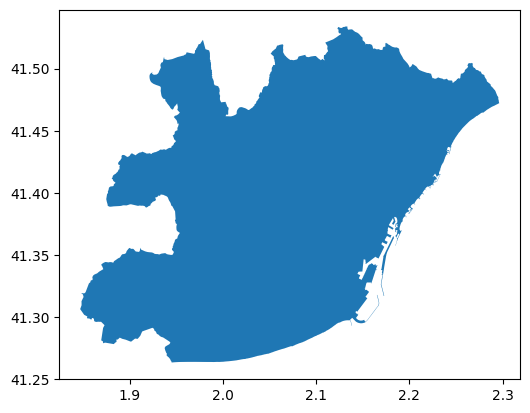

In [2]:
# Importing osmnx

# Define the polygon for the 1st district of Budapest
admin_district = ox.geocode_to_gdf('Àrea Metropolitana de Barcelona, Spain')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [3]:
neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)
neigh = neigh[["name", "geometry"]]
neigh["geometry"] = neigh.buffer(0)


neigh_layer = alt.Chart(neigh).mark_geoshape(
    stroke="black",
    fill="lightblue"
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

In [4]:
metro_sol = pd.read_csv('Nodes/Bus-Sol.csv')
metro = pd.read_csv('Nodes/Bus.csv')

all_stops = pd.concat([metro_sol, metro], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")


In [5]:
bus_sol = pd.read_csv('Nodes/Bus-Sol.csv')
bus = pd.read_csv('Nodes/Bus.csv')
fgc_sol = pd.read_csv('Nodes/FGC-Sol.csv')
fgc = pd.read_csv('Nodes/FGC.csv')
metro_sol = pd.read_csv('Nodes/Metro-Sol.csv')
metro = pd.read_csv('Nodes/Metro.csv')
tram_sol = pd.read_csv('Nodes/Tram-Sol.csv')
tram = pd.read_csv('Nodes/Tram.csv')
destinations = pd.read_csv('Nodes/Destinations.csv')

all_stops = pd.concat([bus_sol, bus, fgc_sol, fgc, metro_sol, metro, tram_sol, tram], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


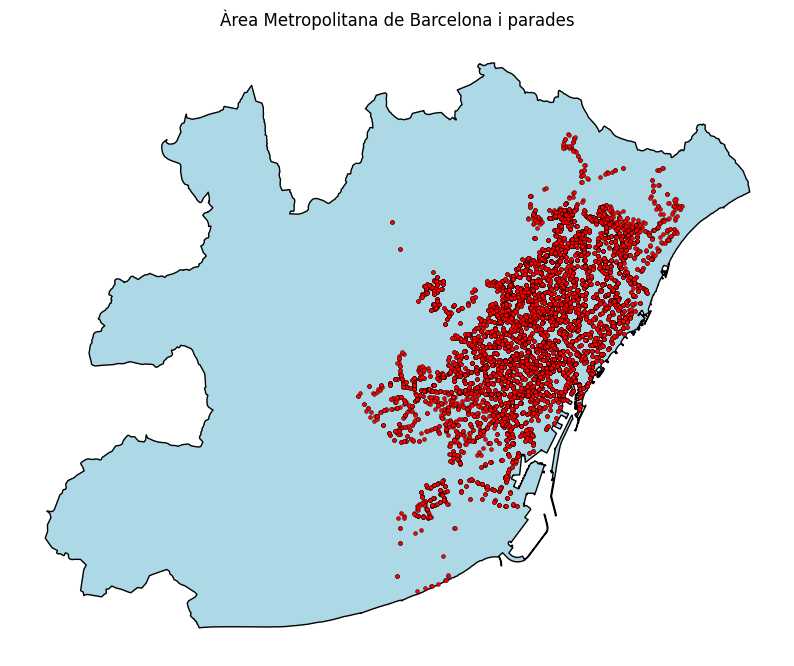

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

admin_district.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=1
)

all_stops.plot(
    ax=ax,
    color="red",
    markersize=8,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Àrea Metropolitana de Barcelona i parades")
ax.axis("off")
plt.show()

In [17]:
walking_speed = 1.39

for u, v, data in G.edges(data=True):
    data["travel_time"] = data["length"] / walking_speed


isochrone_time = 5
isochrone_polys = []

process = 1
for stop in all_stops['stop_id'].unique():
    print(f"Processing stop {stop} ({process}/{len(all_stops['stop_id'].unique())})")
    process += 1
    p = all_stops[all_stops['stop_id'] == stop].iloc[0]
    center_node = ox.distance.nearest_nodes(G, X=p['geometry'].x, Y=p["geometry"].y)

    subgraph = nx.ego_graph(
            G,
            center_node,
            radius= isochrone_time * 60,
            distance="travel_time"
        )

    node_points = [
        Point((data["x"], data["y"]))
        for node, data in subgraph.nodes(data=True)
    ]

    center_point = Point(G.nodes[center_node]["x"], G.nodes[center_node]["y"])

    polygon = gpd.GeoSeries(node_points).union_all().convex_hull
    isochrone_polys.append(
            gpd.GeoDataFrame(
                {"stop_id": [p["stop_id"]], "geometry": [polygon]},
                crs="EPSG:4326"
            )
        )

isochrone_polys = gpd.GeoDataFrame(pd.concat(isochrone_polys, ignore_index=True), crs="EPSG:4326")

Processing stop 2 (1/3342)
Processing stop 3 (2/3342)
Processing stop 4 (3/3342)
Processing stop 7 (4/3342)
Processing stop 8 (5/3342)
Processing stop 12 (6/3342)
Processing stop 13 (7/3342)
Processing stop 15 (8/3342)
Processing stop 16 (9/3342)
Processing stop 17 (10/3342)
Processing stop 18 (11/3342)
Processing stop 20 (12/3342)
Processing stop 21 (13/3342)
Processing stop 22 (14/3342)
Processing stop 24 (15/3342)
Processing stop 25 (16/3342)
Processing stop 27 (17/3342)
Processing stop 28 (18/3342)
Processing stop 29 (19/3342)
Processing stop 30 (20/3342)
Processing stop 31 (21/3342)
Processing stop 32 (22/3342)
Processing stop 34 (23/3342)
Processing stop 36 (24/3342)
Processing stop 38 (25/3342)
Processing stop 39 (26/3342)
Processing stop 41 (27/3342)
Processing stop 42 (28/3342)
Processing stop 43 (29/3342)
Processing stop 44 (30/3342)
Processing stop 47 (31/3342)
Processing stop 48 (32/3342)
Processing stop 51 (33/3342)
Processing stop 52 (34/3342)
Processing stop 54 (35/3342)

KeyboardInterrupt: 

In [16]:
isochrone_polys

,stop_id,geometry
0,2,"POLYGON ((2.19864 41.39029, 2.19655 41.39061, ..."
1,3,"POLYGON ((2.15827 41.38549, 2.15633 41.38565, ..."
2,4,"POLYGON ((2.15993 41.38804, 2.15929 41.38809, ..."
3,7,"POLYGON ((2.16361 41.38233, 2.15976 41.38319, ..."
4,8,"POLYGON ((2.15159 41.36902, 2.14665 41.36923, ..."
...,...,...
495,843,"POLYGON ((2.11535 41.32843, 2.11373 41.32863, ..."
496,844,"POLYGON ((2.11843 41.32504, 2.11736 41.32542, ..."
497,845,"POLYGON ((2.15066 41.4218, 2.1506 41.42183, 2...."
498,847,"POLYGON ((2.14194 41.41035, 2.14108 41.41163, ..."


In [8]:
isocores_df_all = all_stops[all_stops['stop_id'].isin(isochrone_polys['stop_id'].unique())].merge(isochrone_polys, on='stop_id', how='left')
isocores_df_all.drop(columns=['geometry_x'], inplace=True)
isocores_df_all.rename(columns={'geometry_y': 'geometry'}, inplace=True)
isocores_df_all.set_geometry('geometry', inplace=True)
isocores_df_all.head()

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19864 41.39029, 2.19655 41.39061, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15827 41.38549, 2.15633 41.38565, ..."
2,SB-4,4,Mallorca - Balmes,IU Stop,Bus,"POLYGON ((2.15993 41.38804, 2.15929 41.38809, ..."
3,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16361 41.38233, 2.15976 41.38319, ..."
4,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15159 41.36902, 2.14665 41.36923, ..."


In [9]:
test = all_stops.copy()
isocores_df_all_merge =isocores_df_all.copy()
test.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.to_crs('EPSG:25831', inplace=True)
test.rename(columns={'id': 'destination_id','stop_id':'destination_stop_id','name':'destination_stop_name','linia':'destination_linia','stop_type':'destination_stop_type'}, inplace=True)
isocores_df_all_merge.rename(columns={'id': 'origin_id','stop_id':'origin_stop_id','name':'origin_stop_name','linia':'origin_linia','stop_type':'origin_stop_type'}, inplace=True)
close_stops = gpd.sjoin(test[test['destination_id'].isin(isocores_df_all_merge['origin_id'])], isocores_df_all_merge, how='inner', predicate='within')
close_stops = close_stops[close_stops['origin_id'] != close_stops['destination_id']]
close_stops = close_stops[~close_stops['destination_id'].str.startswith('S')]
close_stops = close_stops[['origin_id', 'origin_stop_id', 'origin_stop_type', 'origin_stop_name', 'origin_linia', 'destination_id', 'destination_stop_id', 'destination_stop_type', 'destination_stop_name', 'destination_linia']]
close_stops['tram'] = close_stops['origin_stop_name'] + ' - ' + close_stops['destination_stop_name']
close_stops['mode'] = close_stops['origin_stop_type'] + ' - ' + close_stops['destination_stop_type']
close_stops['lines'] = close_stops['origin_linia'] + ' - ' + close_stops['destination_linia']
close_stops.drop(columns=['origin_stop_name', 'destination_stop_name','origin_stop_type','destination_stop_type','origin_linia','destination_linia'], inplace=True)
close_stops

,origin_id,origin_stop_id,destination_id,destination_stop_id,tram,mode,lines
2235,SB-2,2,B-59-2,2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,SB-34,34,B-59-2,2,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,SB-342,342,B-59-2,2,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,SB-682,682,B-59-2,2,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,SB-698,698,B-59-2,2,Av Icària - Joan Miró - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
...,...,...,...,...,...,...,...
8368,B-19-164,164,M-L5-533,533,Santa Rosalia - Besòs - El Coll | La Teixonera,Bus - Metro,19 - L5
8368,B-119-164,164,M-L5-533,533,Santa Rosalia - Besòs - El Coll | La Teixonera,Bus - Metro,119 - L5
8368,B-H2-164,164,M-L5-533,533,Santa Rosalia - Besòs - El Coll | La Teixonera,Bus - Metro,H2 - L5
8368,B-19-435,435,M-L5-533,533,Arenys - Rossell - El Coll | La Teixonera,Bus - Metro,19 - L5


In [10]:
same_stops = close_stops[
    close_stops['origin_stop_id'] == close_stops['destination_stop_id']
].copy()
same_stops = same_stops.drop(columns=['origin_stop_id', 'destination_stop_id'])

conditions = [
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('T', na=False),
    same_stops['origin_id'].str.startswith('B', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith('M', na=False) & same_stops['destination_id'].str.startswith('M', na=False),
    same_stops['origin_id'].str.startswith('T', na=False) & same_stops['destination_id'].str.startswith('T', na=False),
]
choices = [3, 1, 2, 1, 2, 1]
same_stops['type'] = 'Exchange - Self'
same_stops['time'] = pd.to_timedelta(
    np.select(conditions, choices, default=0),
    unit='m'
)

same_stops['time'] = same_stops['time'].apply(
    lambda x: f"{int(x.total_seconds() // 60):02d}:{int(x.total_seconds() % 60):02d}"
)
same_stops['geometry'] = same_stops.apply(lambda row: all_stops.loc[all_stops['id'] == row['origin_id'], 'geometry'].values[0], axis=1)
same_stops


,origin_id,destination_id,tram,mode,lines,type,time,geometry
2235,SB-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59,Exchange - Self,01:00,POINT (2.198984998801282 41.393104003754864)
2235,B-H16-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,H16 - 59,Exchange - Self,01:00,POINT (2.198984998801282 41.393104003754864)
2235,B-V27-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,V27 - 59,Exchange - Self,01:00,POINT (2.198984998801282 41.393104003754864)
2236,SB-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - H16,Exchange - Self,01:00,POINT (2.198984998801282 41.393104003754864)
2236,B-59-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,59 - H16,Exchange - Self,01:00,POINT (2.198984998801282 41.393104003754864)
...,...,...,...,...,...,...,...,...
8288,SM-216,M-L5-216,Sagrada Família - Sagrada Família,Metro - Metro,IU Stop - L5,Exchange - Self,03:00,POINT (2.17449041 41.40441909)
8288,M-L2-216,M-L5-216,Sagrada Família - Sagrada Família,Metro - Metro,L2 - L5,Exchange - Self,02:00,POINT (2.17449041 41.40441909)
8309,SB-320,M-L3-320,Tarragona - Parc de Joan Miró - Tarragona,Bus - Metro,IU Stop - L3,Exchange - Self,03:00,POINT (2.1474189981579603 41.37670400188018)
8309,B-109-320,M-L3-320,Tarragona - Parc de Joan Miró - Tarragona,Bus - Metro,109 - L3,Exchange - Self,00:00,POINT (2.1474189981579603 41.37670400188018)


In [11]:
different_stops = close_stops[
    (close_stops['origin_stop_id'] != close_stops['destination_stop_id'])
]
different_stops.drop(columns=['origin_stop_id', 'destination_stop_id'], inplace=True)
len(different_stops)

/var/folders/95/s4thp5290fd41pw2cj8713k80000gn/T/ipykernel_76220/1607039356.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  different_stops.drop(columns=['origin_stop_id', 'destination_stop_id'], inplace=True)


18451

In [12]:
# cache_dir = Config().CACHE_DIR
# for f in cache_dir.glob("*.mapdb*"):
#     f.unlink()

In [13]:
transport_network = r5py.TransportNetwork(
    "Data/Neigh/cataluna-260811.osm.pbf",
    elevation_model =["Data/Neigh/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1786456535055.tif"]
    )

In [14]:
different_stops = close_stops[
    (close_stops['origin_stop_id'] != close_stops['destination_stop_id'])
]
different_stops.drop(columns=['origin_stop_id', 'destination_stop_id'], inplace=True)

/var/folders/95/s4thp5290fd41pw2cj8713k80000gn/T/ipykernel_76220/1175124381.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  different_stops.drop(columns=['origin_stop_id', 'destination_stop_id'], inplace=True)


In [15]:
different_stops

,origin_id,destination_id,tram,mode,lines
2235,SB-34,B-59-2,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,SB-342,B-59-2,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,SB-682,B-59-2,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,SB-698,B-59-2,Av Icària - Joan Miró - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
2235,B-H16-34,B-59-2,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,H16 - 59
...,...,...,...,...,...
8368,B-19-164,M-L5-533,Santa Rosalia - Besòs - El Coll | La Teixonera,Bus - Metro,19 - L5
8368,B-119-164,M-L5-533,Santa Rosalia - Besòs - El Coll | La Teixonera,Bus - Metro,119 - L5
8368,B-H2-164,M-L5-533,Santa Rosalia - Besòs - El Coll | La Teixonera,Bus - Metro,H2 - L5
8368,B-19-435,M-L5-533,Arenys - Rossell - El Coll | La Teixonera,Bus - Metro,19 - L5


In [ ]:


itineraries = pd.DataFrame()
process = 0
for _, row in different_stops.iterrows():
    process += 1
    print(f"Processing {process}/{len(different_stops)}")
    origin_id = row['origin_id']
    destination_id = row['destination_id']
    origins = all_stops[all_stops['id'] == origin_id].copy()
    destinations = all_stops[all_stops['id'] == destination_id].copy()
    origins.rename(columns={'origin_id': 'id'}, inplace=True)
    destinations.rename(columns={'destination_id': 'id'}, inplace=True)
    origins = gpd.GeoDataFrame(origins, geometry='geometry', crs="EPSG:4326")
    destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
    detailed_itineraries = r5py.DetailedItineraries(
        transport_network,
        origins=origins,
        destinations=destinations,
        transport_modes=[r5py.TransportMode.WALK],
        snap_to_network=False,
    )
    exchange_time = detailed_itineraries['travel_time'].sum()
    itineraries_row = pd.DataFrame({
        'origin_id': [origin_id],
        'destination_id': [destination_id],
        'tram': [row['tram']],
        'mode': [row['mode']],
        'lines': [row['lines']],
        'type': 'Exchange',
        'time': [exchange_time],
        'geometry': [detailed_itineraries['geometry'].iloc[0]],
    })

    itineraries_row = gpd.GeoDataFrame(itineraries_row, geometry='geometry', crs="EPSG:4326")
    itineraries = pd.concat([itineraries, itineraries_row], ignore_index=True)

itineraries["time"] = itineraries["time"].apply(
    lambda x: f"{int(x.total_seconds() // 60):02d}:{int(x.total_seconds() % 60):02d}"
)
different_stops = itineraries.copy()

/var/folders/95/s4thp5290fd41pw2cj8713k80000gn/T/ipykernel_70966/4240969071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  different_stops.drop(columns=['origin_stop_id', 'destination_stop_id'], inplace=True)


Processing 1/18451
Processing 2/18451
Processing 3/18451
Processing 4/18451
Processing 5/18451
Processing 6/18451
Processing 7/18451
Processing 8/18451
Processing 9/18451
Processing 10/18451
Processing 11/18451
Processing 12/18451
Processing 13/18451
Processing 14/18451
Processing 15/18451
Processing 16/18451
Processing 17/18451
Processing 18/18451
Processing 19/18451
Processing 20/18451
Processing 21/18451
Processing 22/18451
Processing 23/18451
Processing 24/18451
Processing 25/18451
Processing 26/18451
Processing 27/18451
Processing 28/18451
Processing 29/18451
Processing 30/18451
Processing 31/18451
Processing 32/18451
Processing 33/18451
Processing 34/18451
Processing 35/18451
Processing 36/18451
Processing 37/18451
Processing 38/18451
Processing 39/18451
Processing 40/18451
Processing 41/18451
Processing 42/18451
Processing 43/18451
Processing 44/18451
Processing 45/18451
Processing 46/18451
Processing 47/18451
Processing 48/18451
Processing 49/18451
Processing 50/18451
Processin

In [15]:
all_exchanges = pd.concat([same_stops, different_stops], ignore_index=True)
all_exchanges.rename(columns={'origin_id': 'origen', 'destination_id': 'dest','exchange_time':'time'}, inplace=True)
all_exchanges = gpd.GeoDataFrame(all_exchanges, geometry='geometry', crs="EPSG:4326")
all_exchanges = all_exchanges[all_exchanges['time'] <= '05:00']
all_exchanges.insert(7, 'directed', True)

In [20]:
all_exchanges[all_exchanges['mode'] == 'Bus - Metro'].sort_values(by='time').head(10)

,origen,dest,tram,mode,lines,type,time,directed,geometry
4589,B-19-216,M-L2-216,Padilla - Provença - Sagrada Família,Bus - Metro,19 - L2,Exchange - Self,00:00,True,POINT (2.17622 41.4065)
4590,B-V21-216,M-L2-216,Padilla - Provença - Sagrada Família,Bus - Metro,V21 - L2,Exchange - Self,00:00,True,POINT (2.17622 41.4065)
4594,B-19-216,M-L5-216,Padilla - Provença - Sagrada Família,Bus - Metro,19 - L5,Exchange - Self,00:00,True,POINT (2.17622 41.4065)
4595,B-V21-216,M-L5-216,Padilla - Provença - Sagrada Família,Bus - Metro,V21 - L5,Exchange - Self,00:00,True,POINT (2.17622 41.4065)
4599,B-109-320,M-L3-320,Tarragona - Parc de Joan Miró - Tarragona,Bus - Metro,109 - L3,Exchange - Self,00:00,True,POINT (2.14742 41.3767)
22649,B-78-493,M-L3-316,Diagonal - Gran Via Carles III - Maria Cristina,Bus - Metro,78 - L3,Exchange,00:52,True,"LINESTRING (2.12525 41.38751, 2.12574 41.38764..."
22648,B-67-493,M-L3-316,Diagonal - Gran Via Carles III - Maria Cristina,Bus - Metro,67 - L3,Exchange,00:52,True,"LINESTRING (2.12525 41.38751, 2.12574 41.38764..."
22647,B-63-493,M-L3-316,Diagonal - Gran Via Carles III - Maria Cristina,Bus - Metro,63 - L3,Exchange,00:52,True,"LINESTRING (2.12525 41.38751, 2.12574 41.38764..."
22646,B-33-493,M-L3-316,Diagonal - Gran Via Carles III - Maria Cristina,Bus - Metro,33 - L3,Exchange,00:52,True,"LINESTRING (2.12525 41.38751, 2.12574 41.38764..."
22645,B-7-493,M-L3-316,Diagonal - Gran Via Carles III - Maria Cristina,Bus - Metro,7 - L3,Exchange,00:52,True,"LINESTRING (2.12525 41.38751, 2.12574 41.38764..."


In [17]:
isocores_df_all[isocores_df_all['name'].str.startswith('Ctra Nacional 152')]

,id,stop_id,name,linia,stop_type,geometry
64,SB-115,115,Ctra Nacional 152 - Bifurcació,IU Stop,Bus,"POLYGON ((2.1795 41.46435, 2.17762 41.46637, 2..."
158,SB-259,259,Ctra Nacional 152 - Av l'Alzinar,IU Stop,Bus,"POLYGON ((2.18646 41.45858, 2.1807 41.45877, 2..."
657,B-96-115,115,Ctra Nacional 152 - Bifurcació,96,Bus,"POLYGON ((2.1795 41.46435, 2.17762 41.46637, 2..."
908,B-62-259,259,Ctra Nacional 152 - Av l'Alzinar,62,Bus,"POLYGON ((2.18646 41.45858, 2.1807 41.45877, 2..."
909,B-96-259,259,Ctra Nacional 152 - Av l'Alzinar,96,Bus,"POLYGON ((2.18646 41.45858, 2.1807 41.45877, 2..."
910,B-104-259,259,Ctra Nacional 152 - Av l'Alzinar,104,Bus,"POLYGON ((2.18646 41.45858, 2.1807 41.45877, 2..."


In [21]:
all_exchanges.to_csv('Edges/Exchanges.csv', index=False)

In [35]:
all_stops['stop_type'].unique()

array(['Bus', 'FGC', 'Metro', 'Tram'], dtype=object)

In [30]:
not_self_exchanges[not_self_exchanges['dest'] =='M-L4-420']

,origen,dest,tram,mode,lines,type,time,directed,geometry
22795,SB-697,M-L4-420,Pallars - Zamora - Bogatell,Bus - Metro,IU Stop - L4,Exchange,04:24,True,"LINESTRING (2.19107 41.3961, 2.19055 41.39572,..."
22796,SB-835,M-L4-420,Pujades - Àlaba - Bogatell,Bus - Metro,IU Stop - L4,Exchange,02:47,True,"LINESTRING (2.1936 41.3964, 2.19337 41.39623, ..."
22800,B-6-697,M-L4-420,Pallars - Zamora - Bogatell,Bus - Metro,6 - L4,Exchange,04:24,True,"LINESTRING (2.19107 41.3961, 2.19055 41.39572,..."
22801,B-H14-697,M-L4-420,Pallars - Zamora - Bogatell,Bus - Metro,H14 - L4,Exchange,04:24,True,"LINESTRING (2.19107 41.3961, 2.19055 41.39572,..."
22802,B-6-835,M-L4-420,Pujades - Àlaba - Bogatell,Bus - Metro,6 - L4,Exchange,02:47,True,"LINESTRING (2.1936 41.3964, 2.19337 41.39623, ..."
22803,B-B25-835,M-L4-420,Pujades - Àlaba - Bogatell,Bus - Metro,B25 - L4,Exchange,02:47,True,"LINESTRING (2.1936 41.3964, 2.19337 41.39623, ..."
22804,B-B20-835,M-L4-420,Pujades - Àlaba - Bogatell,Bus - Metro,B20 - L4,Exchange,02:47,True,"LINESTRING (2.1936 41.3964, 2.19337 41.39623, ..."
22805,B-136-835,M-L4-420,Pujades - Àlaba - Bogatell,Bus - Metro,136 - L4,Exchange,02:47,True,"LINESTRING (2.1936 41.3964, 2.19337 41.39623, ..."


In [ ]:
# Frame 1: polygons only
alt.data_transformers.enable("vegafusion")
polys_df = isocores_df_all[['id', 'geometry']].copy()
polys_df = gpd.GeoDataFrame(polys_df, geometry='geometry', crs="EPSG:4326")


not_self_exchanges = all_exchanges[all_exchanges['type'] == 'Exchange'].copy()
not_self_exchanges = not_self_exchanges[not_self_exchanges['mode'] == 'Bus - Tram']
origens = not_self_exchanges['origen'].unique().tolist()
destinations = not_self_exchanges['dest'].unique().tolist()
stops =  origens + destinations

isochrone_chart = alt.Chart(polys_df[polys_df['id'].isin(origens)]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['id'].isin(stops)]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(not_self_exchanges).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
neigh_layer + isochrone_chart + points + itineraries_chart  ).properties(
    width=900,
    height=900
)

alt.LayerChart(...)

In [33]:
neigh_layer

alt.Chart(...)

In [ ]:



# ---------------------------------------------------------
# Load neighbourhoods
# ---------------------------------------------------------

neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)

neigh = neigh[["name", "geometry"]]

neigh["geometry"] = neigh.geometry.buffer(0)


# ---------------------------------------------------------
# Prepare itinerary data
# ---------------------------------------------------------

itineraries["mode"] = itineraries["transport_mode"].astype(str)

itineraries["travel time (min)"] = itineraries["travel_time"].apply(
    lambda t: round(t.total_seconds() / 60.0, 2)
)

itineraries["trip"] = itineraries.apply(
    lambda row: f"{row['from_id']} → {row['to_id']}",
    axis=1
)


# ---------------------------------------------------------
# Create map
# ---------------------------------------------------------



detailed_routes_map = (
    itineraries[
        [
            "geometry",
            "distance",
            "mode",
            "travel time (min)",
            "from_id",
            "to_id",
            "trip",
            "option",
            "segment",
        ]
    ]
    .explore(
        tooltip=[
            "trip",
            "option",
            "segment",
            "mode",
            "travel time (min)",
            "distance",
        ],
        column="mode",
        tiles="CartoDB.Positron",
        style_kwds={
            "weight": 3,
            "opacity": 0.8,
        },
        highlight_kwds={
            "weight": 6,
            "opacity": 1,
        },
    )
)


isochrone_polys.explore(
    m=detailed_routes_map,
    tooltip=["stop_id"],
    style_kwds={
        "fillOpacity": 0.15,
        "weight": 1,
    },
)

# ---------------------------------------------------------
# Get stops involved in the itineraries
# ---------------------------------------------------------

stop_ids = pd.unique(
    pd.concat([
        itineraries["from_id"],
        itineraries["to_id"]
    ])
)

stops_map = all_stops[
    all_stops["id"].isin(stop_ids)
].copy()

stops_map = gpd.GeoDataFrame(
    stops_map,
    geometry="geometry",
    crs="EPSG:4326"
)


# ---------------------------------------------------------
# Assign neighbourhood to each stop
# ---------------------------------------------------------

# Project both layers for the spatial join
stops_projected = stops_map.to_crs("EPSG:25831")
neigh_projected = neigh.to_crs("EPSG:25831")

stops_map = gpd.sjoin(
    stops_projected,
    neigh_projected[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Return to WGS84 for Folium
stops_map = stops_map.to_crs("EPSG:4326")


# ---------------------------------------------------------
# Add stop markers
# ---------------------------------------------------------

stops_map.apply(
    lambda row: folium.Marker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        tooltip=(
            f"Stop: {row['id']}<br>"
        ),
        icon=folium.plugins.BeautifyIcon(
            icon_shape="marker",
            number=str(row["id"]),
            border_color="#728224",
            text_color="#728224",
        ),
    ).add_to(detailed_routes_map),
    axis=1,
)


detailed_routes_map